### Implementing simple chatbot using langgraph

In [1]:
 from typing_extensions import TypedDict
 from langgraph.graph import StateGraph, START, END

 ## Reducers
 from typing import Annotated
 from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GEMINI_API_KEY"]=os.getenv("GEMINI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [4]:
from google import genai

client = genai.Client()
response = client.models.generate_content(
    model="gemini-2.5-flash-lite", contents="Explain how AI works in a few words"
)
print(response.text)

AI learns from data to make decisions or perform tasks.


In [5]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="openai/gpt-oss-20b")
llm_groq.invoke("Hey I am Yuval and I like to play cricket")

AIMessage(content='Hey Yuval! That’s awesome—cricket can be a lot of fun. Do you play for a local club, or do you just enjoy watching the matches? What’s your favorite role on the field? 🏏', additional_kwargs={'reasoning_content': 'The user says: "Hey I am Yuval and I like to play cricket". We should respond with a friendly response, perhaps ask about cricket. No policy issues. Just greet.'}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 82, 'total_tokens': 175, 'completion_time': 0.098036675, 'completion_tokens_details': {'reasoning_tokens': 38}, 'prompt_time': 0.006643113, 'prompt_tokens_details': None, 'queue_time': 0.051058863, 'total_time': 0.104679788}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019df67f-69f3-76f3-a4b6-44cb047cc270-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 82, 

### We Will start With Creating Nodes

In [6]:
def superbot(state:State):
    return {"messages": [llm_groq.invoke(state["messages"])]}

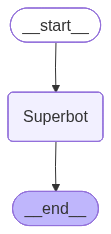

In [7]:
graph = StateGraph(State)

## Node
graph.add_node("Superbot",superbot)

## Edges
graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder = graph.compile()

## Display
from IPython.display import display,Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [8]:
## Invocation

graph_builder.invoke({"messages":"hey, My name is Yuval and I like to play cricket"})

{'messages': [HumanMessage(content='hey, My name is Yuval and I like to play cricket', additional_kwargs={}, response_metadata={}, id='a08c29c3-0e99-421a-bebc-5c9fefafc994'),
  AIMessage(content='Hey Yuval! 👋 Great to meet a fellow cricket fan. Which format do you enjoy most—T20, ODI, or the longer Test games? And do you have a favorite team or player you follow?', additional_kwargs={'reasoning_content': 'User says "hey, My name is Yuval and I like to play cricket". We should respond accordingly. They are introducing themselves. We can greet them, mention cricket, ask about their favorite team or player, maybe discuss cricket. Keep friendly.'}, response_metadata={'token_usage': {'completion_tokens': 104, 'prompt_tokens': 84, 'total_tokens': 188, 'completion_time': 0.105668284, 'completion_tokens_details': {'reasoning_tokens': 51}, 'prompt_time': 0.004654154, 'prompt_tokens_details': None, 'queue_time': 0.048604065, 'total_time': 0.110322438}, 'model_name': 'openai/gpt-oss-20b', 'system

In [9]:
## Streaming the response

for event in graph_builder.stream({"messages":"Hello My name is KRish"}):
    print(event)

{'Superbot': {'messages': [AIMessage(content='Hello KRish! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hello My name is KRish". We should respond with a friendly greeting and ask how we can help.'}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 77, 'total_tokens': 125, 'completion_time': 0.055377226, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.004469725, 'prompt_tokens_details': None, 'queue_time': 0.049185522, 'total_time': 0.059846951}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019df67f-f32c-70b3-bf01-92ed7f7cea5c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 48, 'total_tokens': 125, 'output_token_details': {'reasoning': 26}})]}}


In [ ]:
for event in graph_builder.stream({"messages":"Hello My name is KRish"},stream_nodes="values"):
    print(event)